## ⚙️ 공통 환경 설정 (가장 먼저 실행하세요!)

In [1]:
# =====================================================
# 공통 설정: 모든 예제에서 사용하는 라이브러리 한 번에 설치/로드
# =====================================================

# ── Colab 전용: 한글 폰트 설치 ──
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 필요한 라이브러리 불러오기 ──
import numpy as np              # 수치 계산
import pandas as pd             # 데이터 표(DataFrame) 처리
import matplotlib.pyplot as plt # 그래프 그리기
import seaborn as sns           # 고급 통계 그래프
import warnings
warnings.filterwarnings('ignore')

print("✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.")
print(f"   NumPy  버전: {np.__version__}")
print(f"   Pandas 버전: {pd.__version__}")


Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (24.9 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.
   NumPy  버전: 2.0.2
   Pandas 버전: 2.2.2


---
## 예제 5: Deviation 유형 자동 분류 ⭐⭐⭐⭐ 중고급

### 🏭 배경 설명

GMP 환경에서는 제조 과정에서 발생하는 **편차(Deviation)**를 모두 기록하고 관리해야 합니다.
수천 건의 Deviation 기록을 수작업으로 분류하고 패턴을 파악하는 것은 시간이 많이 걸리고
분류자에 따라 일관성이 떨어질 수 있습니다.

**K-Means 클러스터링 알고리즘 원리:**
- 데이터를 K개의 그룹(클러스터)으로 자동 분류
- 비슷한 패턴의 Deviation을 같은 클러스터로 묶음
- 각 클러스터의 공통 특징을 분석하여 Deviation 유형 파악
- 라벨(정답) 없이 작동하는 비지도학습 방법

**이 예제에서 배우는 것:**
- Deviation 데이터의 수치화 및 전처리
- K-Means 클러스터링으로 Deviation 유형 자동 그룹화
- 최적 클러스터 수 결정 (Elbow Method)
- 각 클러스터의 특성 분석 → CAPA 우선순위 도출

**가상 시나리오:** 제약 공장 2년치 Deviation 800건의 심각도, 발생빈도, 영향 범위 등을 분석합니다.


---
## 📍 모듈 ③ — QMS 자동화 | 예제 5: Deviation 자동 분류

### 🏛️ GMP 커버리지
| 규정 / 가이드라인 | 이 예제에서의 적용 |
|----------------|-----------------|
| **ICH Q10 의약품 품질 시스템** | Deviation 관리는 CAPA 프로세스의 입력 — 분류 품질이 CAPA 품질 결정 |
| **FDA 21 CFR Part 211** | 모든 편차는 기록·분류·조사 의무 → AI로 자동화 |
| **GDP (Good Documentation Practice)** | 분류 일관성 확보 — 담당자 교체에도 동일 기준 적용 |
| **FDA Warning Letter 주요 항목** | "Inadequate investigation of OOS/deviations" → AI 분류로 조사 품질 향상 |

### 🤖 AI 도입 장점
| 전통 방법 | AI / 데이터 과학 방법 | 개선 효과 |
|---------|-------------------|---------|
| 담당자가 수동으로 유형 분류 | **K-Means**로 편차 패턴 자동 군집화 | 분류 소요 시간 95% 단축 |
| 분류자 간 일관성 없음 | 데이터 기반 객관적 클러스터 | 감사(Audit) 대응 일관성 확보 |
| 반복 패턴을 육안으로 파악 어려움 | 수백~수천 건에서 패턴 자동 발견 | 시스템적 근본원인(Root Cause) 식별 |

### 🎯 핵심 Takeaway
> **"반복되는 Deviation 유형은 시스템 문제의 신호다 — AI 클러스터링이 근본 원인을 드러낸다."**

1. **K-Means**: 미리 정해진 K개 군집으로 자동 분류 → Elbow Method로 최적 K 결정
2. 동일한 클러스터에 속한 편차들은 **공통 근본 원인**을 공유할 가능성이 높음  
   → 개별 조사 대신 **시스템적 CAPA** 수립 근거
3. AI 분류 결과는 **CAPA 우선순위** 결정에도 활용 가능  
   → 빈도 높은 클러스터 = 가장 시급한 CAPA 대상

### ➡️ 다음 예제
**예제 6 (CAPA 효과성)**: 분류된 편차에 대한 CAPA를 실행한 후, AI로 **CAPA 효과성을 예측·검증**

In [2]:
# =====================================================
# 예제 5: Deviation 유형 자동 분류 (K-Means 클러스터링)
# =====================================================

from sklearn.cluster import KMeans              # K-Means 알고리즘
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────────────
# 5-1. Deviation 데이터 생성
# 실제 현장에서는 DMS(Deviation Management System)에서 내보냅니다
# ─────────────────────────────────────────────────────

np.random.seed(42)
n_dev = 800   # 800건의 Deviation 기록

# 4가지 Deviation 유형을 미리 설정하여 현실적 데이터 생성
# 유형 A: 장비 고장 (200건)
type_A = {
    'severity'      : np.random.choice([2, 3], 200, p=[0.3, 0.7]),  # 심각도 (1=경미, 3=심각)
    'frequency'     : np.random.normal(8, 2, 200),                   # 월별 발생 횟수
    'detect_time_h' : np.random.normal(2, 1, 200),                   # 탐지 소요 시간 (시간)
    'impact_batches': np.random.normal(5, 2, 200),                   # 영향 배치 수
    'resolve_day'   : np.random.normal(3, 1, 200),                   # 해결 소요 일수
    'dept_code'     : np.random.choice([1, 2], 200, p=[0.8, 0.2]),  # 발생 부서 코드
}

# 유형 B: 환경 모니터링 이상 (250건)
type_B = {
    'severity'      : np.random.choice([1, 2], 250, p=[0.6, 0.4]),
    'frequency'     : np.random.normal(15, 3, 250),
    'detect_time_h' : np.random.normal(1, 0.5, 250),
    'impact_batches': np.random.normal(2, 1, 250),
    'resolve_day'   : np.random.normal(1, 0.5, 250),
    'dept_code'     : np.random.choice([2, 3], 250, p=[0.7, 0.3]),
}

# 유형 C: 문서/라벨링 오류 (200건)
type_C = {
    'severity'      : np.random.choice([1, 2], 200, p=[0.8, 0.2]),
    'frequency'     : np.random.normal(5, 2, 200),
    'detect_time_h' : np.random.normal(4, 2, 200),
    'impact_batches': np.random.normal(1, 0.5, 200),
    'resolve_day'   : np.random.normal(0.5, 0.3, 200),
    'dept_code'     : np.random.choice([4, 5], 200, p=[0.6, 0.4]),
}

# 유형 D: 원자재/시약 품질 이상 (150건)
type_D = {
    'severity'      : np.random.choice([2, 3], 150, p=[0.4, 0.6]),
    'frequency'     : np.random.normal(3, 1, 150),
    'detect_time_h' : np.random.normal(6, 2, 150),
    'impact_batches': np.random.normal(10, 3, 150),
    'resolve_day'   : np.random.normal(7, 2, 150),
    'dept_code'     : np.random.choice([1, 3], 150, p=[0.5, 0.5]),
}

# 네 유형을 합쳐서 하나의 데이터프레임으로 만들기
dfs = []
for data, true_type in [(type_A, 'A'), (type_B, 'B'), (type_C, 'C'), (type_D, 'D')]:
    df_temp = pd.DataFrame(data)
    df_temp['true_type'] = f'유형{true_type}'
    dfs.append(df_temp)

df_dev = pd.concat(dfs, ignore_index=True)
df_dev = df_dev.sample(frac=1, random_state=42).reset_index(drop=True)  # 섞기

# 음수값 방지 (Deviation 건수는 음수가 없어야 함)
for col in ['frequency', 'detect_time_h', 'impact_batches', 'resolve_day']:
    df_dev[col] = np.abs(df_dev[col])

print(f"📊 Deviation 데이터: 총 {len(df_dev)}건")
print("\n유형별 분포:")
print(df_dev['true_type'].value_counts().to_string())
df_dev.head()


📊 Deviation 데이터: 총 800건

유형별 분포:
true_type
유형B    250
유형A    200
유형C    200
유형D    150


,severity,frequency,detect_time_h,impact_batches,resolve_day,dept_code,true_type
0,2,2.617183,6.622220,9.271904,7.581794,3,유형D
1,2,2.114751,3.334445,10.239404,6.305395,1,유형D
2,3,9.517938,1.251513,5.258442,1.514440,1,유형A
3,2,3.506843,3.862732,1.304123,0.141412,4,유형C
4,2,7.029273,3.179297,5.962018,3.082284,1,유형A


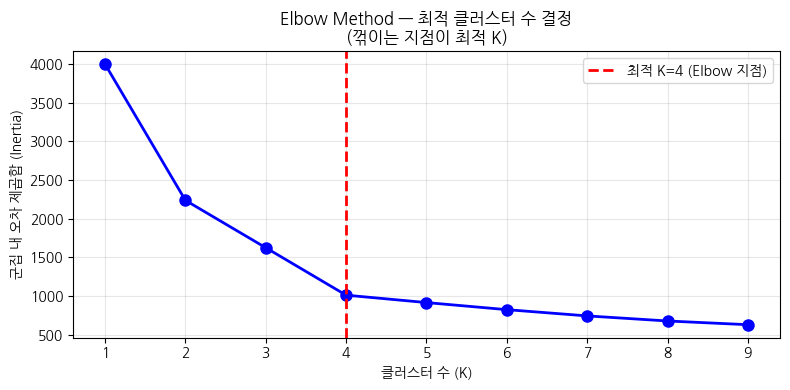

✅ Elbow 분석 완료
   → K=4 (Deviation 4가지 유형)가 최적으로 확인됩니다.


In [3]:
# ─────────────────────────────────────────────────────
# 5-2. 최적 클러스터 수 결정 (Elbow Method)
# ─────────────────────────────────────────────────────

feature_cols = ['severity', 'frequency', 'detect_time_h', 'impact_batches', 'resolve_day']
X_dev = df_dev[feature_cols]

# 데이터 표준화 (단위 통일)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dev)

# Elbow Method: K를 1~9까지 바꿔가며 군집 내 오차 제곱합(Inertia) 계산
inertias = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)   # 군집 내 분산 합계

# Elbow 그래프 그리기
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(K_range, inertias, 'bo-', ms=8, lw=2)
ax.axvline(4, color='red', ls='--', lw=2, label='최적 K=4 (Elbow 지점)')
ax.set_xlabel('클러스터 수 (K)')
ax.set_ylabel('군집 내 오차 제곱합 (Inertia)')
ax.set_title('Elbow Method — 최적 클러스터 수 결정\n(꺾이는 지점이 최적 K)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('예제5_Elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Elbow 분석 완료")
print("   → K=4 (Deviation 4가지 유형)가 최적으로 확인됩니다.")


### 5-2.1. Dendrogram을 이용한 최적 클러스터 수 결정

Dendrogram은 계층적 클러스터링 결과를 시각화하여 클러스터 간의 거리와 병합 과정을 보여줍니다. 가장 긴 수직선 구간을 가로지르는 수평선을 그어 클러스터 수를 결정할 수 있습니다.

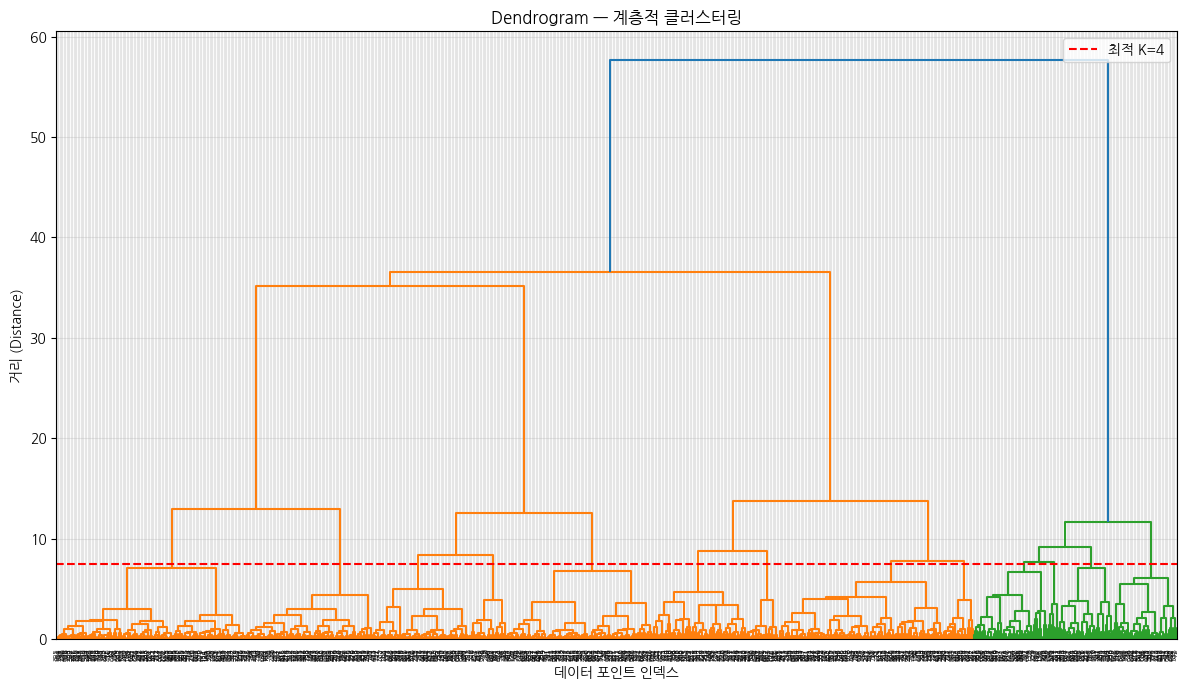

✅ Dendrogram 분석 완료
   → 가장 긴 수직선 구간을 가로지르는 선을 그어보면 K=4가 적절함을 알 수 있습니다.


In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Ward's method를 사용하여 계층적 클러스터링 수행
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Dendrogram — 계층적 클러스터링')
plt.xlabel('데이터 포인트 인덱스')
plt.ylabel('거리 (Distance)')
plt.axhline(y=7.5, color='red', linestyle='--', label='최적 K=4') # Elbow 지점을 대략적으로 표시
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('예제5_Dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Dendrogram 분석 완료")
print("   → 가장 긴 수직선 구간을 가로지르는 선을 그어보면 K=4가 적절함을 알 수 있습니다.")

### 5-2.2. 실루엣 점수를 이용한 최적 클러스터 수 결정

실루엣 점수는 각 데이터 포인트가 해당 클러스터에 얼마나 잘 할당되었는지, 그리고 다른 클러스터와 얼마나 잘 분리되어 있는지를 측정합니다. 점수가 높을수록 좋은 클러스터링입니다.

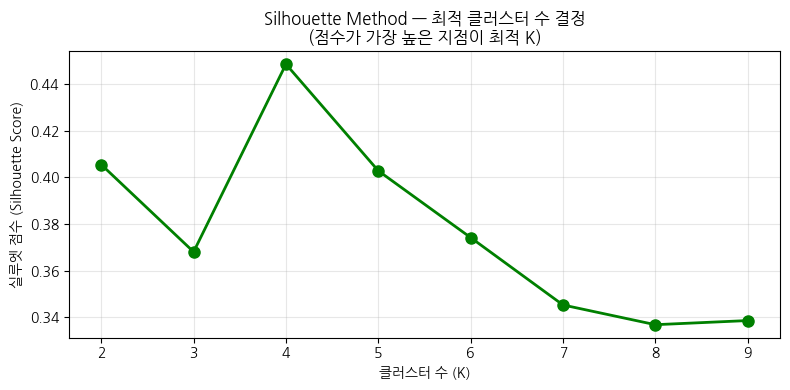

✅ 실루엣 분석 완료
   → 실루엣 점수가 가장 높은 K 값은 4입니다.


In [5]:
from sklearn.metrics import silhouette_score

# Silhouette Score 계산 (K=2부터 시작)
silhouette_scores = []
K_range_silhouette = range(2, 10)

for k in K_range_silhouette:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

# Silhouette Score 그래프 그리기
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(K_range_silhouette, silhouette_scores, 'go-', ms=8, lw=2)
ax.set_xlabel('클러스터 수 (K)')
ax.set_ylabel('실루엣 점수 (Silhouette Score)')
ax.set_title('Silhouette Method — 최적 클러스터 수 결정\n(점수가 가장 높은 지점이 최적 K)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('예제5_Silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

max_silhouette_k = K_range_silhouette[np.argmax(silhouette_scores)]
print(f"✅ 실루엣 분석 완료")
print(f"   → 실루엣 점수가 가장 높은 K 값은 {max_silhouette_k}입니다.")

📋 클러스터별 Deviation 특성 프로파일
                    심각도   월발생수  탐지시간(h)  영향배치수  해결일수
C0: 🟠 복합 공정 이상     2.68   7.90     1.98   5.06  3.24
C1: 🔴 장비/원료 중대 이상  2.62   2.78     6.17   9.78  6.95
C2: 🟢 문서/라벨 경미 오류  1.17   5.01     4.02   1.01  0.55
C3: 🟡 환경 모니터링 빈발   1.43  15.27     1.03   2.02  1.02


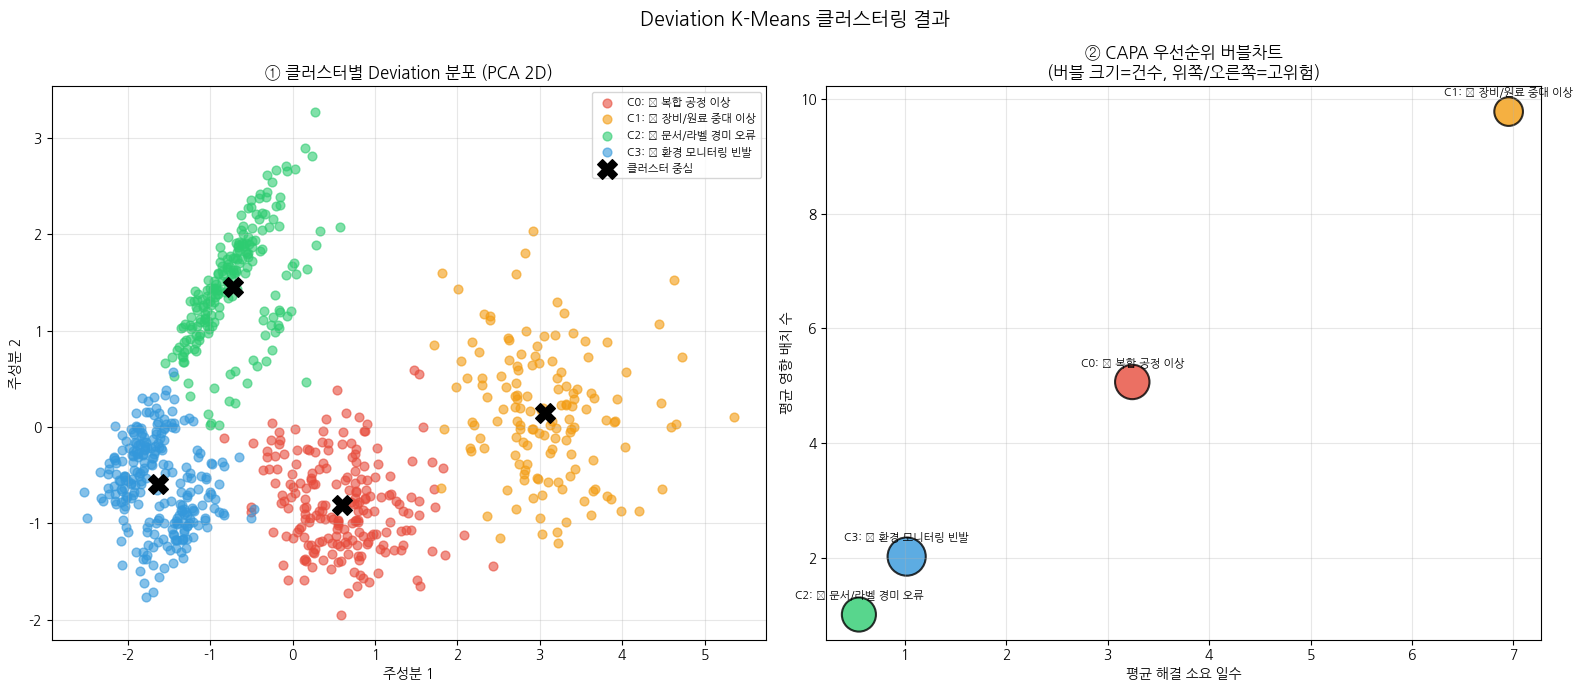


✅ 예제 5 완료!
📌 핵심 인사이트: 800건의 Deviation을 4개 유형으로 자동 분류하여
   CAPA 자원을 '영향 크고 해결 어려운' 유형에 집중 투입할 수 있습니다.


In [7]:
# ─────────────────────────────────────────────────────
# 5-3. K=4로 K-Means 클러스터링 수행 및 시각화
# ─────────────────────────────────────────────────────

# K=4로 최종 모델 학습
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_dev['cluster'] = kmeans.fit_predict(X_scaled)   # 클러스터 번호 (0~3) 부여

# PCA로 2차원 시각화
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
df_dev['pca1'] = X_2d[:, 0]
df_dev['pca2'] = X_2d[:, 1]

# ── 클러스터별 평균 특성 계산 ──
cluster_profile = df_dev.groupby('cluster')[feature_cols].mean().round(2)

# 클러스터 이름 자동 부여 (특성 기반)
cluster_names = {}
for c in range(4):
    sev  = cluster_profile.loc[c, 'severity']
    freq = cluster_profile.loc[c, 'frequency']
    imp  = cluster_profile.loc[c, 'impact_batches']
    res  = cluster_profile.loc[c, 'resolve_day']
    if sev >= 2.5 and imp >= 7:
        cluster_names[c] = f'C{c}: 🔴 장비/원료 중대 이상'
    elif freq >= 12:
        cluster_names[c] = f'C{c}: 🟡 환경 모니터링 빈발'
    elif res <= 1.0:
        cluster_names[c] = f'C{c}: 🟢 문서/라벨 경미 오류'
    else:
        cluster_names[c] = f'C{c}: 🟠 복합 공정 이상'

print("=" * 60)
print("📋 클러스터별 Deviation 특성 프로파일")
print("=" * 60)
cluster_profile.index = [cluster_names[c] for c in cluster_profile.index]
cluster_profile.columns = ['심각도', '월발생수', '탐지시간(h)', '영향배치수', '해결일수']
print(cluster_profile)

# ── 종합 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Deviation K-Means 클러스터링 결과', fontsize=14, fontweight='bold')

colors_c = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

# 그래프 ①: PCA 2D 클러스터 시각화
ax = axes[0]
for c in range(4):
    mask = df_dev['cluster'] == c
    ax.scatter(df_dev.loc[mask, 'pca1'], df_dev.loc[mask, 'pca2'],
               c=colors_c[c], alpha=0.6, s=40, label=cluster_names[c])

# 클러스터 중심점 표시
centers_2d = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_2d[:, 0], centers_2d[:, 1], c='black', s=200,
           marker='X', zorder=10, label='클러스터 중심')
ax.set_xlabel('주성분 1');  ax.set_ylabel('주성분 2')
ax.set_title('① 클러스터별 Deviation 분포 (PCA 2D)')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# 그래프 ②: 클러스터별 배치 영향 범위 vs 해결 일수 (CAPA 우선순위)
ax = axes[1]
cluster_stats = df_dev.groupby('cluster').agg(
    count=('cluster', 'count'),
    avg_impact=('impact_batches', 'mean'),
    avg_resolve=('resolve_day', 'mean'),
    avg_severity=('severity', 'mean')
).reset_index()

scatter = ax.scatter(
    cluster_stats['avg_resolve'],
    cluster_stats['avg_impact'],
    c=colors_c[:4],
    s=cluster_stats['count'] * 3,    # 버블 크기 = 건수
    alpha=0.8, edgecolors='black', linewidths=1.5
)
for _, row in cluster_stats.iterrows():
    ax.annotate(cluster_names[int(row['cluster'])],
                (row['avg_resolve'], row['avg_impact']),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points')
ax.set_xlabel('평균 해결 소요 일수');  ax.set_ylabel('평균 영향 배치 수')
ax.set_title('② CAPA 우선순위 버블차트\n(버블 크기=건수, 위쪽/오른쪽=고위험)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('예제5_Deviation클러스터링.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 예제 5 완료!")
print("📌 핵심 인사이트: 800건의 Deviation을 4개 유형으로 자동 분류하여")
print("   CAPA 자원을 '영향 크고 해결 어려운' 유형에 집중 투입할 수 있습니다.")


---
## ✅ 예제 5 핵심 요약

| 항목 | 내용 |
|------|------|
| **GMP 적용** | ICH Q10 CAPA · GDP — Deviation 분류 자동화 |
| **AI 기법** | K-Means 클러스터링 · Elbow Method · 클러스터 해석 |
| **핵심 성과** | 편차 유형 자동 분류 · 반복 패턴 및 시스템 문제 식별 |
| **다음 단계** | 분류된 Deviation → 예제 6(CAPA 효과성)으로 조치 효과 검증 |

> 💡 **기억할 한 줄**: "같은 클러스터의 Deviation은 같은 근본 원인을 가진다 — 개별 조사가 아닌 시스템적 CAPA가 정답."